In [2]:
import nifty8 as ift
import numpy as np
import matplotlib.pyplot as plt

In [3]:
num_rel_data = np.loadtxt('../data/data_txt/fig1-waveform-H.txt')
time_num_rel, strain_num_rel = (num_rel_data[:, 0], num_rel_data[:, 1])

In [ ]:
note="I'm pretty sure this waveform is actually bandfiltered."
print(note)
plt.xlabel('Time (s)')
plt.ylabel('Strain $[10^{-21}]$')
plt.title("Numerical relativity template")
plt.plot(time_num_rel, strain_num_rel)

Now let's:
- Create a `ground truth field` by simply interpolating the array
- Create data by masking the ground truth field and adding some Gaussian, stationary noise, such that our data resembles the real data
- Set up the inference scheme by taking Sebastian's model samples
- IF successful => try to add some non-stationary noise by using a full, (non-stationry) noise matrix (probably HT transform a non-diagonal fourier covariance)
- Check: How bad the power spectrum approximation to the noise is (and if it IS good: Try to get a more realistic noise estimate since you don't really know if the currently in place noise samples are realistic) and then check how the inference fares doing a Variable Covariance Energy inference

In [4]:
num_of_data_points = len(time_num_rel)
resol = num_of_data_points*2

total_time = max(time_num_rel) - min(time_num_rel)

ext_factor = 2

time_domain = ift.DomainTuple.make(ift.RGSpace(shape=(resol,), distances=total_time/resol),)
time_domain_ext = ift.DomainTuple.make(ift.RGSpace(shape=(resol*ext_factor,), distances=total_time/resol),)

time_domain_ground_truth = ift.Field(time_domain, val=np.linspace(min(time_num_rel), max(time_num_rel), resol))
time_domain_ground_truth_ext = ift.Field(time_domain_ext, val=np.linspace(min(time_num_rel), max(time_num_rel)*ext_factor, resol*2))

ground_truth_field = ift.Field(time_domain, val=np.interp(time_domain_ground_truth.val, time_num_rel, strain_num_rel))
# plt.plot(time_domain_ground_truth.val, ground_truth_field.val)

In [5]:
class Mask(ift.LinearOperator):
    # Implements a mask response based on a sampling rate
    def __init__(self, domain, sampling_rate_Hz, physical_start, physical_end):
        # sampling_rate is typically for ligo 4096Hz or 16384Hz
        # physical_start and end have to be correspondingly in seconds
        # Note that in my implementation, the points are probably not exactly equidistantly spaced (because of the `np.floor` function
        # Also domain.shape[0]-1 is so that the last element is definitely not returned as an index
        self._domain = domain

        physical_length_of_domain = physical_end - physical_start
        num_of_points_to_keep = int(sampling_rate_Hz * physical_length_of_domain)


        self._target = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_points_to_keep, )))
        self._capability = self.TIMES | self.ADJOINT_TIMES

        self._where_to_keep = np.floor(np.linspace(0, domain.shape[0]-1, num_of_points_to_keep)).astype(int)
        print("Based on sampling rate, length and shape of domain, keeping ", num_of_points_to_keep, " points.")

    def apply(self, x, mode):
        self._check_input(x, mode)
        # x is a field
        if mode == self.ADJOINT_TIMES:
            # zero-pads
            values = np.zeros(self._domain.shape[0])
            values[self._where_to_keep] = x.val
            return ift.Field(self._domain, values)

        elif mode == self.TIMES:
            extract = np.array(x.val)
            idcs = np.array(self._where_to_keep)
            values = extract[idcs]
            return ift.Field(self._target, values)

mask = Mask(time_domain, sampling_rate_Hz=4096/4, physical_end=max(time_num_rel), physical_start=min(time_num_rel))

Based on sampling rate, length and shape of domain, keeping  214  points.


Text(0.5, 1.0, 'Masked numerical relativity template')

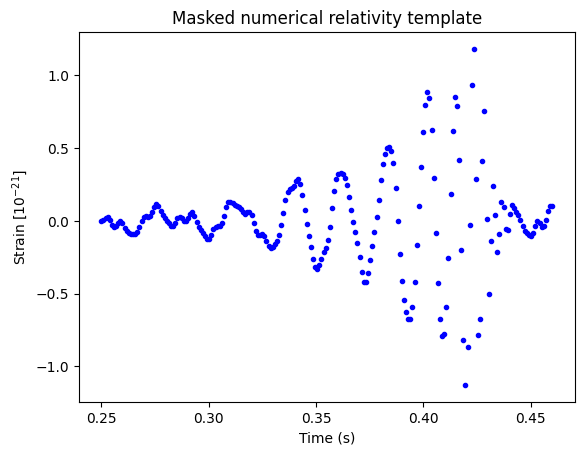

In [6]:
masked_data = mask(ground_truth_field)
masked_time = mask(time_domain_ground_truth)
plt.plot(masked_time.val, masked_data.val, "b.")
plt.ylabel('Strain $[10^{-21}]$')
plt.xlabel('Time (s)')
plt.title("Masked numerical relativity template")

In [7]:
# Add some noise
N = ift.ScalingOperator(masked_data.domain, 0.01, sampling_dtype=np.float64)
d = masked_data + N.draw_sample()

In [ ]:

real_strain_data = np.loadtxt('../data/data_txt/fig1-observed-H.txt')
time, strain = (real_strain_data[:, 0], real_strain_data[:, 1])

plt.plot(masked_time.val, d.val, "r-", label="'Synthetic' data (from numerical rel. template)")
plt.plot(time, strain, "b-", label="Real (cleaned) data from Ligo")
plt.ylabel('Strain $[10^{-21}]$')
plt.xlabel('Time (s)')
plt.title("Data from numerical relativity with added Gaussian noise vs. observed data")
plt.legend()

## Observation:

The noise in the real dataset is obviously absolutely larger during the low S/N regime than in the high S/N regime => Noise decreases in amplitude the close it gets to the peak?

The data from the numerical relativity temaplte looks similar enough (for now) to the real, cleaned data. Now, let's set up the signal model and check whether it is flexible enough to infer this signal.

In [9]:

X = ift.FieldZeroPadder(time_domain, new_shape=(resol*ext_factor,))

s_offset = {
    "offset_mean": 0,
    "offset_std": (1e-20, 1e-21),
}

s_fluctuations = {
    "target_subdomain": time_domain_ext[0],
    "fluctuations": (0.25, 2),
    "loglogavgslope": (-4., 1.),
    "flexibility": (1., 0.5),
    "asperity": (5., 0.5)
    }

s_model = ift.CorrelatedFieldMaker("strain model")
s_model.set_amplitude_total_offset(**s_offset)
s_model.add_fluctuations(**s_fluctuations)

s_model = s_model.finalize()
s_model_cut = X.adjoint(s_model)


Offset amplitude: 1.00E-20 ± 1.07E-21
Total fluctuation amplitude: 1.52E-01 ± 4.06E-01


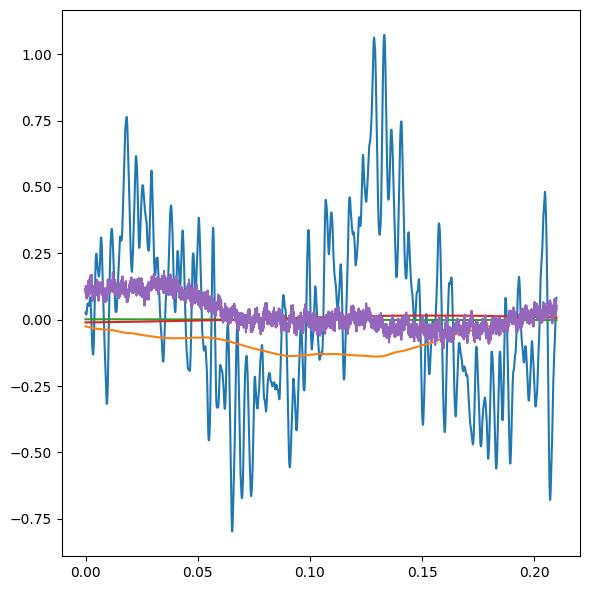

In [10]:
ift.plot_priorsamples(s_model_cut)

Set up the inference scheme

In [11]:
from initial_ideas.utils.minimization_control import *

R = mask @ X.adjoint @ s_model
likelihood_energy = ift.GaussianEnergy(d, N.inverse) @ R


In [12]:

KL_minimizations = 10

posterior_samples, final_pos = ift.optimize_kl(
    likelihood_energy=likelihood_energy,
    total_iterations=KL_minimizations,
    n_samples=kl_sampling_rate,
    kl_minimizer=descent_finder,
    sampling_iteration_controller=ic_sampling_lin,
    nonlinear_sampling_minimizer=geoVI_sampling_minimizer,
    output_directory="out",
    return_final_position=True,
    resume=True)

STARARRT MININMIZERS
ENDENDENE MININMIZERS


                             reduced χ²          mean      # dof
----------------------------------------------------------------
Data residuals
  <None>                      1.3 ± 0.2     0.0 ± 0.0        214
Latent space
  strain modelasperity        0.7 ± 0.7    -0.2 ± 0.8          1
  strain modelflexibility     0.2 ± 0.2     0.1 ± 0.5          1
  strain modelfluctuations    0.9 ± 0.1     1.0 ± 0.0          1
  strain modelloglogavgslope  7.9 ± 3.8     2.7 ± 0.7          1
  strain modelspectrum        1.0 ± 0.0    -0.0 ± 0.0      13758
  strain modelxi              1.0 ± 0.0    -0.0 ± 0.0      13760
  strain modelzeromode        1.2 ± 1.6    -0.0 ± 1.1          1


STARARRT MININMIZERS


                             reduced χ²          mean      # dof
----------------------------------------------------------------
Data residuals
  <None>                      1.0 ± 0.1     0.0 ± 0.1        214
Latent space
  strain modelasperity        0.8 ± 0.8    -0.2 ± 0.9          1
  strain modelflexibility     0.2 ± 0.3     0.3 ± 0.3          1
  strain modelfluctuations    1.1 ± 0.1     1.0 ± 0.0          1
  strain modelloglogavgslope  6.9 ± 3.8     2.5 ± 0.7          1
  strain modelspectrum        1.0 ± 0.0    -0.0 ± 0.0      13758
  strain modelxi              1.0 ± 0.0    -0.0 ± 0.0      13760
  strain modelzeromode        0.9 ± 0.9     0.0 ± 1.0          1


ENDENDENE MININMIZERS
STARARRT MININMIZERS
ENDENDENE MININMIZERS


...

ENDENDENE MININMIZERS
STARARRT MININMIZERS


                             reduced χ²          mean      # dof
----------------------------------------------------------------
Data residuals
  <None>                      0.8 ± 0.1     0.0 ± 0.0        214
Latent space
  strain modelasperity        0.6 ± 1.2     0.1 ± 0.8          1
  strain modelflexibility     0.7 ± 0.7     0.6 ± 0.6          1
  strain modelfluctuations    1.4 ± 0.2     1.2 ± 0.1          1
  strain modelloglogavgslope  3.6 ± 2.7     1.8 ± 0.8          1
  strain modelspectrum        1.0 ± 0.0    -0.0 ± 0.0      13758
  strain modelxi              1.0 ± 0.0     0.0 ± 0.0      13760
  strain modelzeromode        0.3 ± 0.3     0.0 ± 0.5          1


ENDENDENE MININMIZERS
STARARRT MININMIZERS


                             reduced χ²          mean      # dof
----------------------------------------------------------------
Data residuals
  <None>                      0.8 ± 0.1     0.0 ± 0.0        214
Latent space
  strain modelasperity        0.9 ± 1.0    -0.2 ± 0.9          1
  strain modelflexibility     0.6 ± 0.4     0.7 ± 0.3          1
  strain modelfluctuations    1.4 ± 0.2     1.2 ± 0.1          1
  strain modelloglogavgslope  3.5 ± 3.7     1.6 ± 1.0          1
  strain modelspectrum        1.0 ± 0.0    -0.0 ± 0.0      13758
  strain modelxi              1.0 ± 0.0    -0.0 ± 0.0      13760
  strain modelzeromode        0.8 ± 1.0     0.0 ± 0.9          1


ENDENDENE MININMIZERS


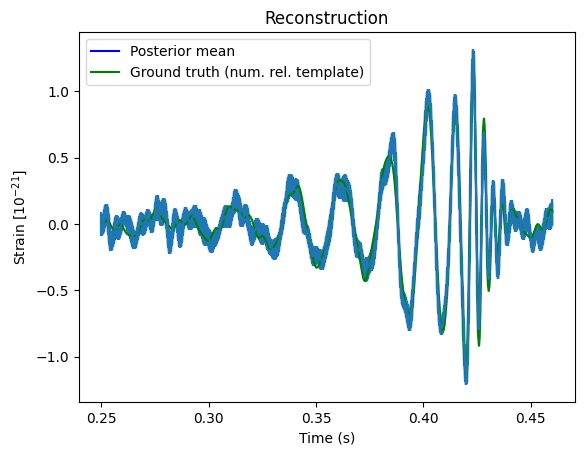

In [31]:
%matplotlib tk
# %matplotlib inline

s_mean, s_var = posterior_samples.sample_stat(s_model)

plt.plot(time_domain_ground_truth.val, X.adjoint(s_mean).val, "b-", label="Posterior mean")
plt.errorbar(time_domain_ground_truth.val, X.adjoint(s_mean).val, yerr=np.sqrt(X.adjoint(s_var).val))  # MEAN WITH VARIANCE
# plt.plot(masked_time.val, d.val, "r-", label="'Synthetic' data (from numerical rel. template)")  # DATA
plt.plot(time_domain_ground_truth.val, ground_truth_field.val, "g-", label="Ground truth (num. rel. template)")

plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Strain $[10^{-21}]$')
plt.title("Reconstruction")
plt.show()


# Results
Looks actually quite excellent ... but the data of course, as is right now, looks extremely informative.
What if we

1. Look at a more complicated ground truth noise structure (non-stationary) and try to:
2. Assume a Gaussian Noise covariance of fixed a level
3. Try to infer the noise alongside the signal via a fixed power spectrum
4. Try to infer the full noise via a variable covariance energy

From the theory side:

a. Could it be that the noise problem can somehow be modelled as a temporally evolving power spectrum? What is the exact source and nature of the non-stationarity?

b. What is this envelope modelling Torsten suggested? Did Sebastian implement this?

c. Looks like VariableCovarianceGaussianEnergy assumes an uncorrelated, diagonal noise covariance structure, so it'd be actually better to infer a noise power spectrum alongside the data

### Comments

b.) It looks like to me that Sebastian actually managed to build the Instrument Response and that in the Instrument Response some kind of envelope is used.

Lets now try to build a non-stationary noise-operator.

In [50]:
num = len(masked_data.val)

class ComplicatedNoiseMatrix(ift.Operator):
    def __init__(self, domain, matrix):
        self._domain = domain
        self._target = domain
        self._mat = matrix
        self._capability = 0 | 1
        self._nl = np.cos

    def apply(self, x, mode=1):
        if mode == 1:
            return ift.Field(self._target, self._mat @ self._nl(x.val))
        elif mode == 0:
            # adjoint
            return ift.Field(self._target, self._mat.H @ self._nl(x.val))

data_domain = masked_data.domain
noise_matrix = np.random.rand(num**2).reshape((num, num,))  # since its random, this matrix should not have structure like homogeneity
base_noise = ComplicatedNoiseMatrix(data_domain, noise_matrix)



In [54]:
base_noise.draw_samples()

AttributeError: 'ComplicatedNoiseMatrix' object has no attribute 'draw_samples'